In [98]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
import gc
import re

In [99]:
from sklearn.model_selection import train_test_split
from wordcloud import WordCloud
from transformers import AutoTokenizer, TFAutoModelForSequenceClassification

Loading Data

In [ ]:
dataset = pd.read_csv('mentalhealth.csv')
dataset = dataset.sample(n=20000).reset_index(drop=True)
dataset.head()

,subreddit,category,id,title,selftext,author,score,num_comments,created_utc,flair,url
0,SuicideWatch,new,1ln98r2,My fantasy is to win the lottery then kill myself,I (f/27) currently live with my parents. I've ...,Hamsterdisaster,3,0,1.751184e+09,NaN,https://www.reddit.com/r/SuicideWatch/comments...
1,depression,hot,1lng66j,I don’t know if I have enough strength to go on,My name is Jose i been dealing with a lot of p...,ohToonz_,1,0,1.751208e+09,NaN,https://www.reddit.com/r/depression/comments/1...
2,SuicideWatch,top_all,q8g9nt,one hour after I tried to kill myself I had a ...,I feel empty,Moloore420,559,69,1.634271e+09,NaN,https://www.reddit.com/r/SuicideWatch/comments...
3,mentalhealth,top_month,1lfv6u8,3 months clean of cutting,I'm 15m and has had severe depression since I ...,minoru_minetatheperv,3,1,1.750394e+09,Content Warning: Suicidal Thoughts / Self Harm,https://www.reddit.com/r/mentalhealth/comments...
4,depression,top_month,1lel2a6,I hate this life more than anyone could ever i...,It’s been years in the same brutal vicious cyc...,reminiscermusic2019,35,6,1.750263e+09,NaN,https://www.reddit.com/r/depression/comments/1...


In [ ]:
dataset.shape

(20000, 11)

In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   subreddit     20000 non-null  object 
 1   category      20000 non-null  object 
 2   id            20000 non-null  object 
 3   title         20000 non-null  object 
 4   selftext      19380 non-null  object 
 5   author        18060 non-null  object 
 6   score         20000 non-null  int64  
 7   num_comments  20000 non-null  int64  
 8   created_utc   20000 non-null  float64
 9   flair         10306 non-null  object 
 10  url           20000 non-null  object 
dtypes: float64(1), int64(2), object(8)
memory usage: 1.7+ MB


In [ ]:
dataset.describe()

,score,num_comments,created_utc
count,20000.000000,20000.000000,2.000000e+04
mean,266.999800,46.205800,1.706556e+09
std,517.305069,184.590746,6.626979e+07
min,0.000000,0.000000,1.328665e+09
25%,5.000000,3.000000,1.714214e+09
50%,45.000000,21.000000,1.734975e+09
75%,269.000000,61.000000,1.750946e+09
max,10130.000000,18644.000000,1.751479e+09


In [ ]:
dataset.isna().sum()

subreddit          0
category           0
id                 0
title              0
selftext         620
author          1940
score              0
num_comments       0
created_utc        0
flair           9694
url                0
dtype: int64

In [ ]:
dataset['num_words'] = dataset['selftext'].astype(str).apply(len)
dataset['num_words'].describe()

count    20000.0000
mean       809.6548
std        965.3361
min          1.0000
25%        274.7500
50%        553.0000
75%       1015.0000
max      31577.0000
Name: num_words, dtype: float64

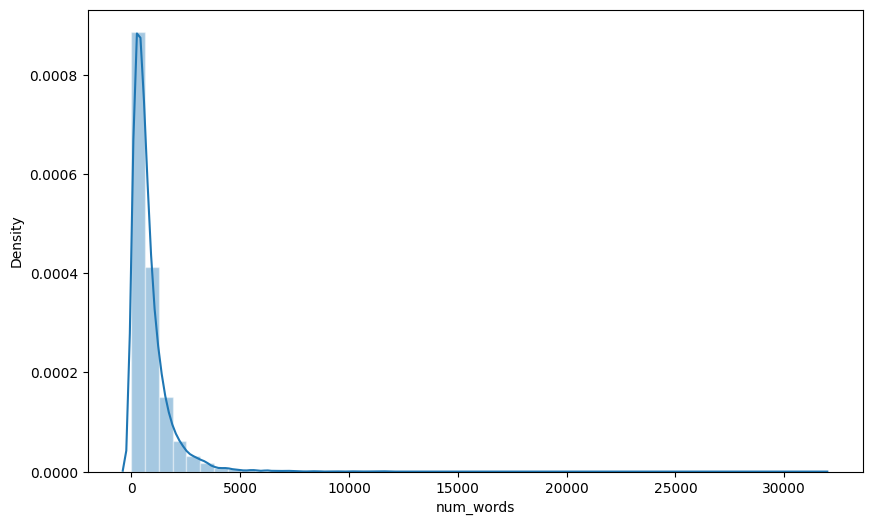

In [ ]:
plt.figure(figsize=(10,6),dpi=100)
fig = sns.histplot(dataset['num_words'], kde=True, stat="density", kde_kws=dict(cut=3), alpha=.4, edgecolor=(1, 1, 1, .4), bins=50)
plt.show(fig)
del fig
plt.close('all')
gc.collect();

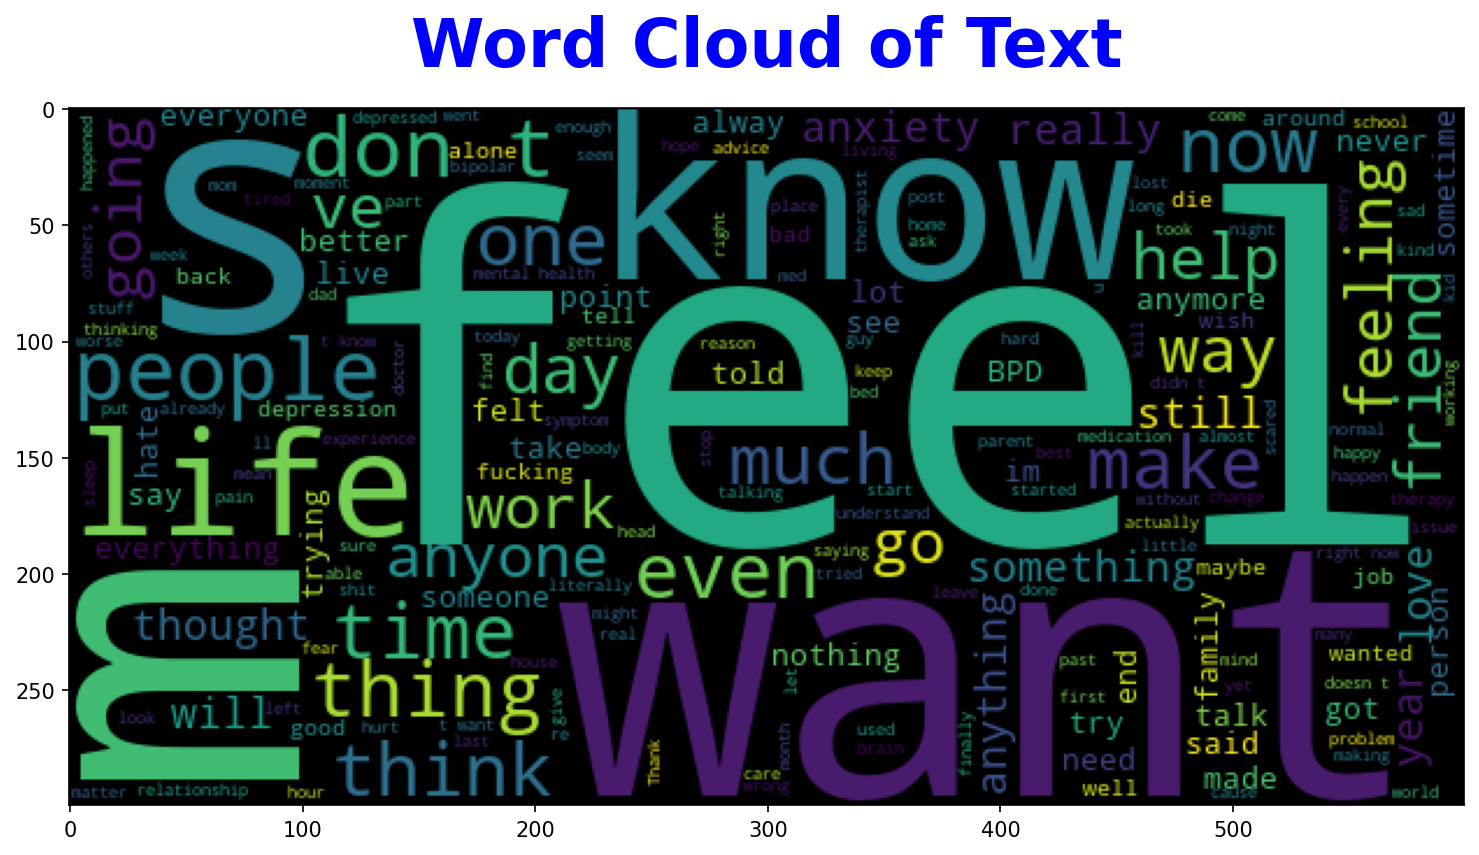

In [ ]:
max_length = 85
plt.figure(figsize=(12,8),dpi=150)
wc = WordCloud(width=600,height=300,random_state=101).generate(' '.join(dataset.astype(str).selftext))
plt.title('Word Cloud of Text',color='blue',fontsize=32,fontweight='bold',pad=20)
plt.imshow(wc);

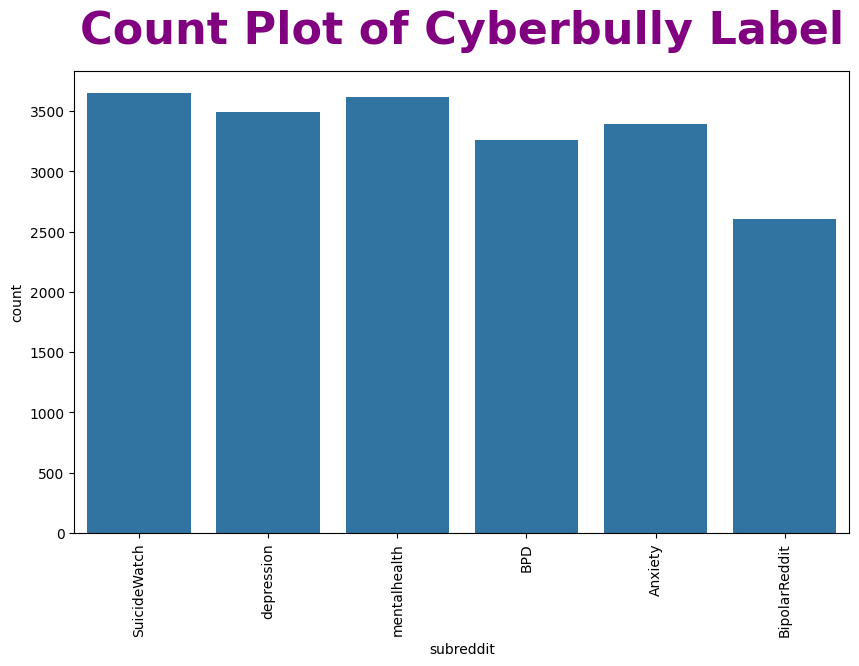

In [ ]:
plt.figure(figsize=(10,6))
fig = sns.countplot(data=dataset,x='subreddit')
plt.title('Count Plot of Cyberbully Label',fontsize=32,pad=20,color='purple',fontweight='bold')
plt.xticks(rotation=90)
plt.show(fig)
del fig
plt.close('all')
gc.collect();

In [ ]:
def clean_text(text):
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\b[a-zA-Z]\b", " ", text)
    text = re.sub(r"<[^>]*>", " ", text)
    text = text.lower()
    text = re.sub(r"\s+", " ", text)
    text = text.strip()
    return text

In [ ]:
def clean_data(data):
    new_data = data[['subreddit','title', 'selftext']].copy()
    new_data.columns = ['subreddit', 'title', 'post']
    posts = new_data['post'].tolist()
    cleaned_posts = [clean_text(str(post)) for post in posts]
    new_data['cleaned_post'] = cleaned_posts
    return new_data

In [ ]:
preprocessed_ds = clean_data(dataset)
preprocessed_ds.head()

,subreddit,title,post,cleaned_post
0,SuicideWatch,My fantasy is to win the lottery then kill myself,I (f/27) currently live with my parents. I've ...,27 currently live with my parents ve been livi...
1,depression,I don’t know if I have enough strength to go on,My name is Jose i been dealing with a lot of p...,my name is jose been dealing with lot of pain ...
2,SuicideWatch,one hour after I tried to kill myself I had a ...,I feel empty,feel empty
3,mentalhealth,3 months clean of cutting,I'm 15m and has had severe depression since I ...,15m and has had severe depression since was 8 ...
4,depression,I hate this life more than anyone could ever i...,It’s been years in the same brutal vicious cyc...,it been years in the same brutal vicious cycle...


In [ ]:
tokenizer = AutoTokenizer.from_pretrained('sreeniketh/cyberbullying_sentiment_dsce_2023')
distilbert = TFAutoModelForSequenceClassification.from_pretrained('sreeniketh/cyberbullying_sentiment_dsce_2023',from_pt=True)

All PyTorch model weights were used when initializing TFDistilBertForSequenceClassification.

All the weights of TFDistilBertForSequenceClassification were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFDistilBertForSequenceClassification for predictions without further training.


In [100]:
train_ds, test_ds = train_test_split(preprocessed_ds,test_size=0.3,random_state=101)

In [102]:
X_train = tokenizer(text=train_ds['selftext'].tolist(),
                   max_length=max_length,
                   padding=True,
                   truncation=True,
                   add_special_tokens=True,
                   return_tensors='tf',
                   return_attention_mask=True,
                   return_token_type_ids=False,
                   verbose=1)

X_test = tokenizer(text=test_ds['selftext'].tolist(),
                  max_length=max_length,
                  padding=True,
                  truncation=True,
                  add_special_tokens=True,
                  return_tensors='tf',
                  return_attention_mask=True,
                  return_token_type_ids=False,
                  verbose=1)

KeyError: 'selftext'